In [1]:

import argparse
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import wandb

%matplotlib inline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
ENTITY  = "behzadshomali"
PROJECT = "loop_MTP_paper"


In [2]:
RUN_IDS = [
    "fv279t18",  # L=7
    "x0dqjrj2" # L=7 wo/ MTP
]

GATE_BIAS_PREFIX_TEMPLATE = "gate_bias_raw_stats gate_bias_raw_stats/iter_{iter}_layer_0"
STEP_COL = "_step"   # actual column name in the W&B history DataFrame

# Colors distinguish runs; marker shapes distinguish seen_steps checkpoints
COLORS_RUNS   = plt.cm.Set2.colors
STEP_MARKERS  = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "p"]

In [3]:
max_iters = 7

api = wandb.Api()
run1 = api.run(f"{ENTITY}/{PROJECT}/{RUN_IDS[0]}")
run2 = api.run(f"{ENTITY}/{PROJECT}/{RUN_IDS[1]}")

# ── Fetch history ───────────────────────────────────────────────────────────
iter_keys = [
    GATE_BIAS_PREFIX_TEMPLATE.replace("{iter}", str(i))
    for i in range(max_iters)
]
history1 = run1.history(keys=iter_keys, pandas=True)
history1 = history1.sort_values(STEP_COL).reset_index(drop=True)
history2 = run2.history(keys=iter_keys, pandas=True)
history2 = history2.sort_values(STEP_COL).reset_index(drop=True)

wandb: Currently logged in as: behzadshomali to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
# Perceptually-uniform, grayscale-safe sequential palette (viridis-derived)
PALETTE_ACL = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.85, max_iters)]

plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             9,
    "axes.titlesize":        10,
    "axes.labelsize":        9,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       8,
    "ytick.labelsize":       8,
    "axes.linewidth":        0.8,
    "xtick.major.width":     0.6,
    "ytick.major.width":     0.6,
    "lines.linewidth":       1.5,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

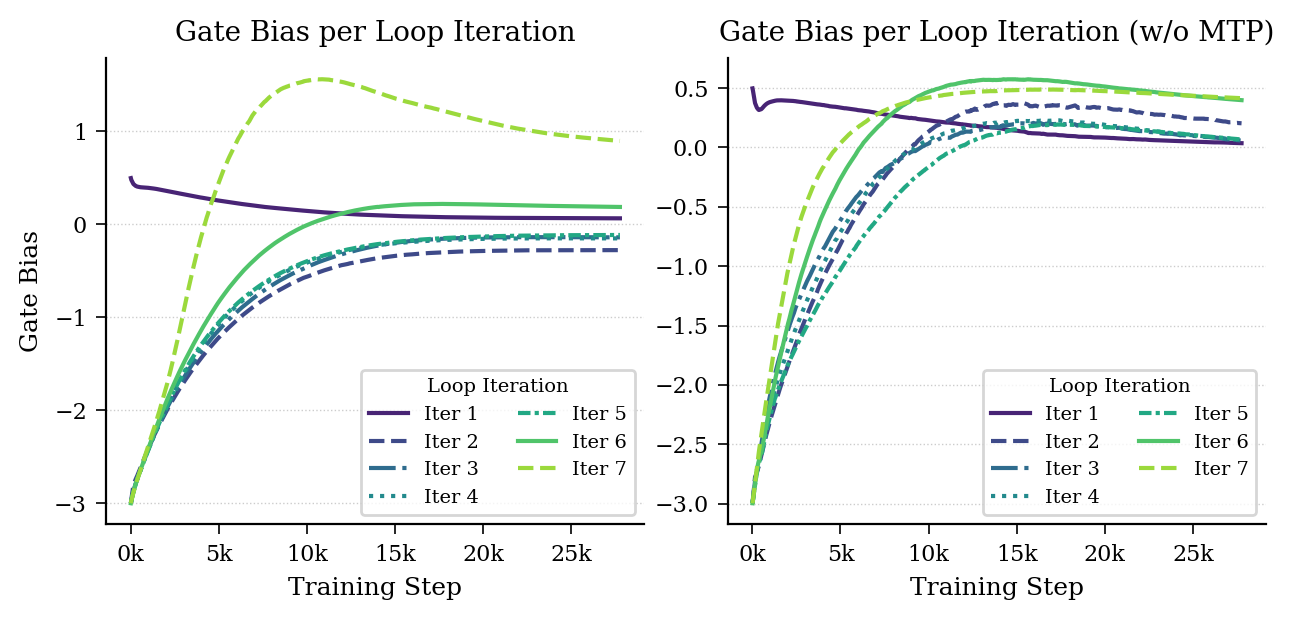

In [5]:

# ── ACL/EMNLP-friendly style ────────────────────────────────────────────────
# Single-column width (3.33 in), LaTeX-matching fonts, grayscale-safe
# Line style varies so the plot is legible when printed in black & white.

LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
# Perceptually-uniform, grayscale-safe sequential palette (viridis-derived)
PALETTE_ACL = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.85, max_iters)]

plt.rcParams.update({
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":      "dejavuserif",
    "font.size":             9,
    "axes.titlesize":        10,
    "axes.labelsize":        9,
    "legend.fontsize":       7,
    "legend.title_fontsize": 7,
    "xtick.labelsize":       8,
    "ytick.labelsize":       8,
    "axes.linewidth":        0.8,
    "xtick.major.width":     0.6,
    "ytick.major.width":     0.6,
    "lines.linewidth":       1.5,
    "figure.dpi":            200,
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
})

fig, ax = plt.subplots(1, 2, figsize=(6.33, 3))   # single-column ACL width

for i, key in enumerate(iter_keys):
    col1   = history1[key].dropna()
    steps = history1.loc[col1.index, STEP_COL]
    ax[0].plot(
        steps,
        col1.values,
        label=f"Iter {i + 1}",
        color=PALETTE_ACL[i],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
    )

    col2   = history2[key].dropna()
    steps = history2.loc[col2.index, STEP_COL]
    ax[1].plot(
        steps,
        col2.values,
        label=f"Iter {i + 1}",
        color=PALETTE_ACL[i],
        linestyle=LINESTYLES[i % len(LINESTYLES)],
    )

ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
ax[0].set_axisbelow(True)

ax[0].set_xlabel("Training Step")
ax[0].set_ylabel("Gate Bias")
ax[0].set_title("Gate Bias per Loop Iteration")
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))
ax[0].legend(title="Loop Iteration", frameon=True, framealpha=0.8,
             edgecolor="#cccccc", loc="best", ncol=2)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
ax[1].set_axisbelow(True)
ax[1].set_xlabel("Training Step")
ax[1].set_title("Gate Bias per Loop Iteration (w/o MTP)")
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x / 1000)}k"))
ax[1].legend(title="Loop Iteration", frameon=True, framealpha=0.8,
             edgecolor="#cccccc", loc="best", ncol=2)

fig.tight_layout(pad=0.4)
fig.savefig("./plots/loop_dynamic_L=5.pdf")
plt.show()


Final Gate Bias Values (with MTP):
Iter 1: 0.0656
Iter 2: -0.2762
Iter 3: -0.1387
Iter 4: -0.1500
Iter 5: -0.1133
Iter 6: 0.1880
Iter 7: 0.8975

Final Gate Bias Values (without MTP):
Iter 1: 0.0364
Iter 2: 0.2040
Iter 3: 0.0578
Iter 4: 0.0618
Iter 5: 0.0671
Iter 6: 0.3989
Iter 7: 0.4155


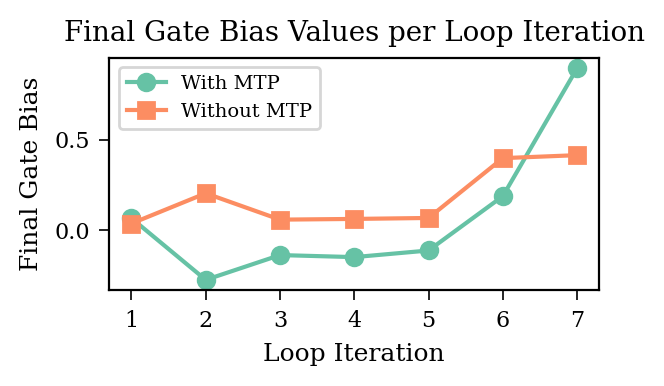

In [6]:
# print the final gate bias values for each iteration
print("Final Gate Bias Values (with MTP):")
for i, key in enumerate(iter_keys):
    final_value = history1[key].dropna().iloc[-1]
    print(f"Iter {i + 1}: {final_value:.4f}")
print("\nFinal Gate Bias Values (without MTP):")
for i, key in enumerate(iter_keys):
    final_value = history2[key].dropna().iloc[-1]
    print(f"Iter {i + 1}: {final_value:.4f}")

# and now plot them
plt.figure(figsize=(3.33, 2))  # single-column ACL width
final_values1 = [history1[key].dropna().iloc[-1] for key in iter_keys]
final_values2 = [history2[key].dropna().iloc[-1] for key in iter_keys]
plt.plot(range(1, max_iters + 1), final_values1, marker="o", label="With MTP", color=COLORS_RUNS[0])
plt.plot(range(1, max_iters + 1), final_values2, marker="s", label="Without MTP", color=COLORS_RUNS[1])
plt.xlabel("Loop Iteration")
plt.ylabel("Final Gate Bias")
plt.title("Final Gate Bias Values per Loop Iteration")
plt.xticks(range(1, max_iters + 1))
plt.legend()
plt.tight_layout()

In [7]:
api = wandb.Api()

max_iters=5
run1 = api.run(f"{ENTITY}/{PROJECT}/e3g7yfid")

/tmp/ipykernel_726979/125394881.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


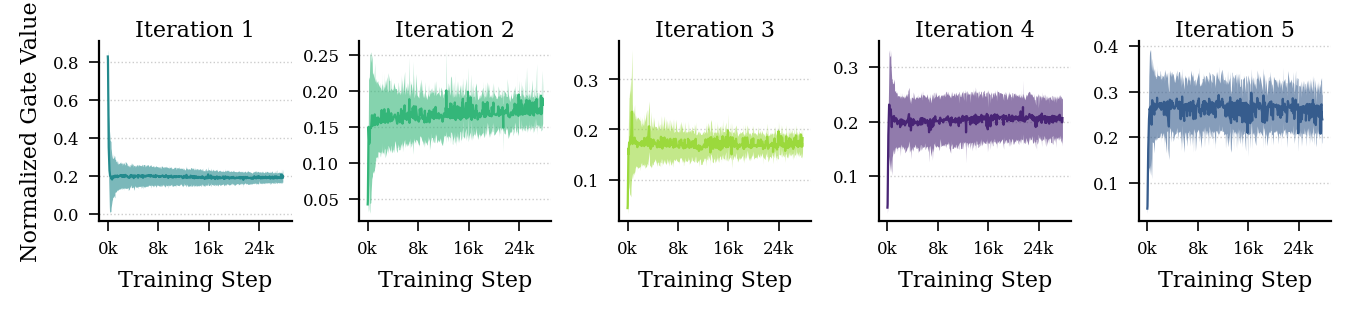

In [8]:

import matplotlib.gridspec as gridspec

LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
# Perceptually-uniform, grayscale-safe sequential palette (viridis-derived)
PALETTE_ACL = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.85, max_iters)]

GATE_VAL_TEMPLATE = (
    "gate_normalized_stats gate_stats/"
    "normalized_gate_{iter}_normalized_layer_0_iter_{iter}"
)
GATE_STD_TEMPLATE = (
    "gate_normalized_std_tokens_stats gate_normalized_stats_std/"
    "normalized_gate_{iter}_normalized_std_tokens_layer_0_iter_{iter}"
)

gate_val_keys = [GATE_VAL_TEMPLATE.replace("{iter}", str(i)) for i in range(max_iters)]
gate_std_keys = [GATE_STD_TEMPLATE.replace("{iter}", str(i)) for i in range(max_iters)]

history_gates = run1.history(keys=gate_val_keys + gate_std_keys, pandas=True)
history_gates = history_gates.sort_values("_step").reset_index(drop=True)

# ── Layout: top row 3 panels, bottom row 2 panels centered ──────────────────
L, R = 0.09, 0.97          # left / right margins of the plot area
offset = (R - L) / 6      # half a column width → centers 2 out of 3

gs_top = gridspec.GridSpec(1, 5, left=L,          right=R,          top=0.90, bottom=0.6, wspace=0.35)
gs_bot = gridspec.GridSpec(1, 2, left=L + offset, right=R - offset, top=0.4, bottom=0.10, wspace=0.5)

fig = plt.figure(figsize=(7.0, 3))

axes_top = [fig.add_subplot(gs_top[0, 0])]
axes_top += [fig.add_subplot(gs_top[0, j],) for j in range(1, 5)]
# axes_bot  = [fig.add_subplot(gs_bot[0, j],) for j in range(2)]
axes_bot  = []
axes_all  = axes_top + axes_bot

for i, (val_key, std_key) in enumerate(zip(gate_val_keys, gate_std_keys)):
    ax = axes_all[i]

    val_col = history_gates[val_key].dropna()
    steps   = history_gates.loc[val_col.index, "_step"]
    std_col = history_gates.loc[val_col.index, std_key]

    color = PALETTE_ACL[(i+2) % 5]
    ax.plot(steps, val_col.values, color=color, linewidth=0.8)
    ax.fill_between(steps,
                    val_col.values - std_col.values,
                    val_col.values + std_col.values,
                    color=color, alpha=0.6, linewidth=0)

    ax.set_title(f"Iteration {i + 1}", fontsize=8, pad=1)
    ax.set_xlabel("Training Step", fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=6)

    if i == 0:
        ax.set_ylabel("Normalized Gate Value", fontsize=8)

    ## hide y-axis decorations for non-leftmost panels in each row
    # row_first = (i == 0) or (i == 3)
    # if not row_first:
    #     ax.spines["left"].set_visible(False)
    #     ax.tick_params(left=False)
    #     plt.setp(ax.get_yticklabels(), visible=False)

# fig.text(0.035, 0.52, "Normalized Gate Value", va="center",
        #  rotation="vertical", fontsize=8)
# fig.suptitle("Normalized Gate Value per Loop Iteration", fontsize=10, y=1.02)
plt.tight_layout(pad=0.4)
fig.savefig("./plots/gate_normalized_L=5.pdf")
plt.show()


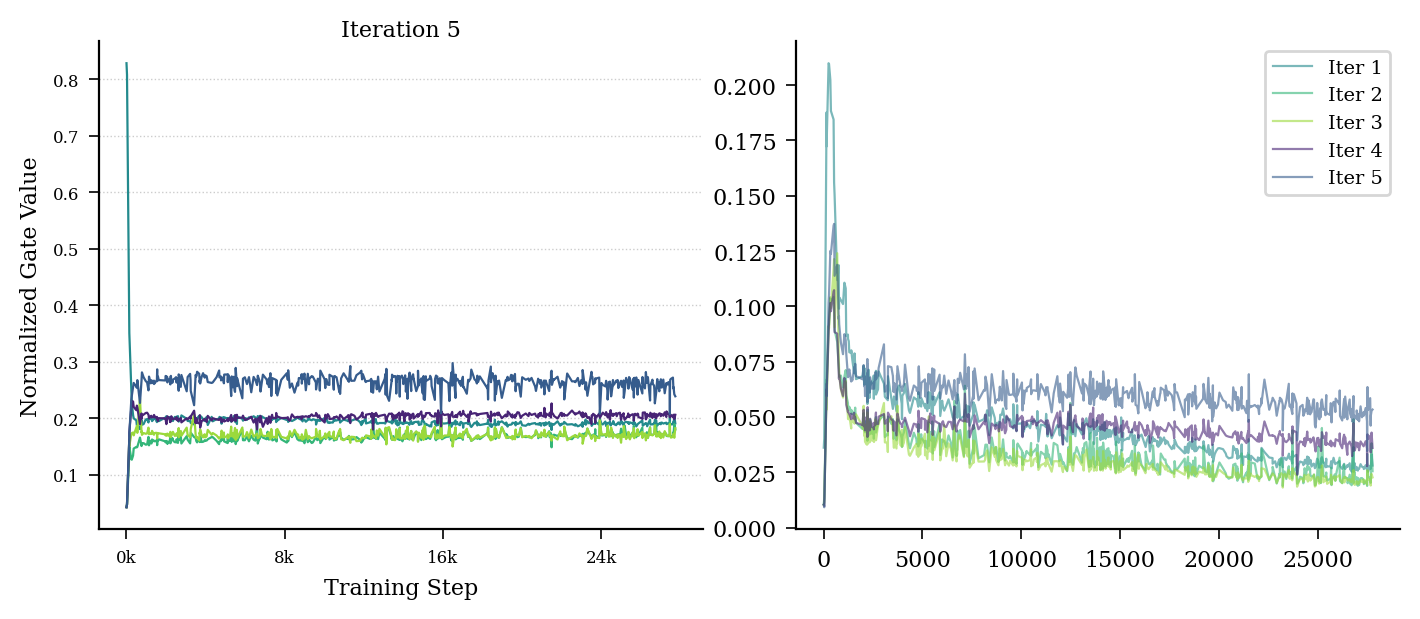

In [9]:

import matplotlib.gridspec as gridspec

LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
# Perceptually-uniform, grayscale-safe sequential palette (viridis-derived)
PALETTE_ACL = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.85, max_iters)]

GATE_VAL_TEMPLATE = (
    "gate_normalized_stats gate_stats/"
    "normalized_gate_{iter}_normalized_layer_0_iter_{iter}"
)
GATE_STD_TEMPLATE = (
    "gate_normalized_std_tokens_stats gate_normalized_stats_std/"
    "normalized_gate_{iter}_normalized_std_tokens_layer_0_iter_{iter}"
)

gate_val_keys = [GATE_VAL_TEMPLATE.replace("{iter}", str(i)) for i in range(max_iters)]
gate_std_keys = [GATE_STD_TEMPLATE.replace("{iter}", str(i)) for i in range(max_iters)]

history_gates = run1.history(keys=gate_val_keys + gate_std_keys, pandas=True)
history_gates = history_gates.sort_values("_step").reset_index(drop=True)

# ── Layout: top row 3 panels, bottom row 2 panels centered ──────────────────
L, R = 0.09, 0.97          # left / right margins of the plot area
offset = (R - L) / 6      # half a column width → centers 2 out of 3

gs_top = gridspec.GridSpec(1, 5, left=L,          right=R,          top=0.90, bottom=0.6, wspace=0.35)
gs_bot = gridspec.GridSpec(1, 2, left=L + offset, right=R - offset, top=0.4, bottom=0.10, wspace=0.5)

# fig = plt.figure(figsize=(7.0, 3))
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.0, 3))


# axes_top = [fig.add_subplot(gs_top[0, 0])]
# axes_top += [fig.add_subplot(gs_top[0, j],) for j in range(1, 5)]
# axes_bot  = [fig.add_subplot(gs_bot[0, j],) for j in range(2)]
# axes_bot  = []
# axes_all  = axes_top + axes_bot

for i, (val_key, std_key) in enumerate(zip(gate_val_keys, gate_std_keys)):
    # ax = axes_all[i]

    val_col = history_gates[val_key].dropna()
    steps   = history_gates.loc[val_col.index, "_step"]
    std_col = history_gates.loc[val_col.index, std_key]

    color = PALETTE_ACL[(i+2) % 5]
    ax.plot(steps, val_col.values, color=color, linewidth=0.8)
    
    # ax2.fill_between(steps,
    #                 val_col.values - std_col.values,
    #                 val_col.values + std_col.values,
    #                 color=color, alpha=0.6, linewidth=0)
    ax2.plot(steps, std_col.values, color=color, linewidth=0.8, alpha=0.6, label=f"Iter {i + 1}",)

    ax.set_title(f"Iteration {i + 1}", fontsize=8, pad=1)
    ax.set_xlabel("Training Step", fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, color="#aaaaaa")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=6)

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    if i == 0:
        ax.set_ylabel("Normalized Gate Value", fontsize=8)

    ax2.legend()

    ## hide y-axis decorations for non-leftmost panels in each row
    # row_first = (i == 0) or (i == 3)
    # if not row_first:
    #     ax.spines["left"].set_visible(False)
    #     ax.tick_params(left=False)
    #     plt.setp(ax.get_yticklabels(), visible=False)

# fig.text(0.035, 0.52, "Normalized Gate Value", va="center",
        #  rotation="vertical", fontsize=8)
# fig.suptitle("Normalized Gate Value per Loop Iteration", fontsize=10, y=1.02)
plt.tight_layout(pad=0.4)
fig.savefig("./plots/gate_normalized_L=5.pdf")
plt.show()
